In [3]:
import torch
import torchvision
from PIL import Image

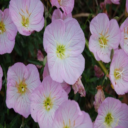

In [4]:
size = (128,128)
transform = torchvision.transforms.Compose([torchvision.transforms.Resize(size), torchvision.transforms.ToTensor()])
train_dataset = list(torchvision.datasets.Flowers102("./flowers", 'train', transform=transform, download = True))
test_dataset = list(torchvision.datasets.Flowers102("./flowers", 'test', transform=transform, download = True))


def visualize_image(img: torch.Tensor) ->Image.Image:
    return Image.fromarray((img.permute(1,2,0) * 255).to(torch.uint8).numpy())

visualize_image(train_dataset[0][0])

In [5]:
#first need to concat the image tensors into one big tensor

train_images = torch.stack([im for im,_ in train_dataset], dim = 0)
train_labels = torch.Tensor([label for _, label in train_dataset])

print(train_images.shape)
print(train_labels.shape)

torch.Size([1020, 3, 128, 128])
torch.Size([1020])


In [8]:
train_images, train_labels = train_images.cuda(), train_labels.cuda()

In [24]:
model = torch.nn.Linear(128*128*3, 102)
model.cuda()

loss = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr = .001)

In [27]:
batch_size = 32
for epoch in range(100):
    avg_loss = []
    #batch sgd
    for i in range(0,len(train_images), 32):
        #by indexing directly into we lose batch dim, so use None to keep if we are only selecting one val
        out = model(train_images[ i:i+batch_size].view(-1,128*128*3))
        optimizer.zero_grad()
        l = loss(out, train_labels[ i:i+batch_size].long())
        l.backward()
        optimizer.step()
        avg_loss.append(float(l))
    print(f"Epoch {epoch}, Loss {sum(avg_loss)/len(avg_loss):.4}")

Epoch 0, Loss 1.909
Epoch 1, Loss 1.875
Epoch 2, Loss 1.856
Epoch 3, Loss 1.824
Epoch 4, Loss 1.791
Epoch 5, Loss 1.758
Epoch 6, Loss 1.725
Epoch 7, Loss 1.694
Epoch 8, Loss 1.663
Epoch 9, Loss 1.633
Epoch 10, Loss 1.603
Epoch 11, Loss 1.574
Epoch 12, Loss 1.546
Epoch 13, Loss 1.518
Epoch 14, Loss 1.491
Epoch 15, Loss 1.465
Epoch 16, Loss 1.439
Epoch 17, Loss 1.413
Epoch 18, Loss 1.388
Epoch 19, Loss 1.364
Epoch 20, Loss 1.34
Epoch 21, Loss 1.317
Epoch 22, Loss 1.294
Epoch 23, Loss 1.271
Epoch 24, Loss 1.249
Epoch 25, Loss 1.228
Epoch 26, Loss 1.207
Epoch 27, Loss 1.186
Epoch 28, Loss 1.166
Epoch 29, Loss 1.147
Epoch 30, Loss 1.127
Epoch 31, Loss 1.108
Epoch 32, Loss 1.09
Epoch 33, Loss 1.072
Epoch 34, Loss 1.054
Epoch 35, Loss 1.037
Epoch 36, Loss 1.02
Epoch 37, Loss 1.003
Epoch 38, Loss 0.9868
Epoch 39, Loss 0.9709
Epoch 40, Loss 0.9553
Epoch 41, Loss 0.94
Epoch 42, Loss 0.925
Epoch 43, Loss 0.9104
Epoch 44, Loss 0.896
Epoch 45, Loss 0.8819
Epoch 46, Loss 0.8682
Epoch 47, Loss 0.8547

# 3.7

In [36]:
size = (128,128)
transform = torchvision.transforms.Compose([torchvision.transforms.Resize(size), torchvision.transforms.ToTensor()])
train_dataset = torchvision.datasets.Flowers102("./flowers", 'train', transform=transform, download = True)
test_dataset = torchvision.datasets.Flowers102("./flowers", 'test', transform=transform, download = True)


def visualize_image(img: torch.Tensor) ->Image.Image:
    return Image.fromarray((img.permute(1,2,0) * 255).to(torch.uint8).numpy())

# visualize_image(train_dataset[0][0])

In [37]:
#data set is list of transformed images
#implements __len__() and __getitem__()
train_dataset

Dataset Flowers102
    Number of datapoints: 1020
    Root location: ./flowers
    split=train
    StandardTransform
Transform: Compose(
               Resize(size=(128, 128), interpolation=bilinear, max_size=None, antialias=True)
               ToTensor()
           )

In [38]:
#has args like batch size, shuffle bool, num workers,
# help(torch.utils.data.DataLoader)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size = 64, shuffle = True)
train_loader

In [49]:
class myModel(torch.nn.Module):
    #use a param that is the list of each layer size
    def __init__(self, layer_size = [512,512,512]):
        super(myModel,self).__init__()
        layers = []
        #flatten layer will take any image an flatten to vector!
        c = 128*128*3 #channels, initial is our size
        layers.append(torch.nn.Flatten())#?
        for i in layer_size:
            #initially go 128*128*3 to 512 then 512 to 512 etc
            layers.append(torch.nn.Linear(c, i))
            layers.append(torch.nn.ReLU())
            c = i
        #last layer needs to map to output size
        #no relu!
        layers.append(torch.nn.Linear(c,102))
        #sequential will create a network where layers are called in order
        self.model = torch.nn.Sequential(*layers)
    def forward(self, x):
        #forward is us just calling the model
        return self.model(x)

model = myModel(layer_size = [])
model.cuda()
loss_fn = torch.nn.CrossEntropyLoss() 
optim = torch.optim.SGD(model.parameters(), lr = .001)

In [50]:
#dataloader gives iterator so can't index into
#but can iterate over
#this is slower bc each time the data loader goes to disk and loads batch
#which is inefficient
#other issue is that originally not on gpu.
for epoch in range(10):
    for imgs, labels in train_loader:
        imgs,labels = imgs.cuda(), labels.cuda()
        pred = model(imgs)
        loss_val = loss_fn(pred, labels)
        loss_val.backward()
        optim.step()
        print(loss_val.item())

4.665635585784912
4.621094703674316
4.702566146850586
4.699163436889648
4.718138694763184
4.6366963386535645
4.8556928634643555
5.017236709594727
4.944969177246094
4.933524131774902
5.06321907043457
4.894134044647217
4.848372459411621
4.81770133972168
4.806705474853516
5.036070823669434
4.306069374084473
4.575884819030762
4.17511510848999
4.237025260925293
4.135519981384277
4.474080562591553
4.7207794189453125
5.195305824279785
4.7598419189453125
4.749698638916016
4.621413230895996
4.651844024658203
4.852118492126465
4.804744243621826
3.6730237007141113
3.5375523567199707
4.113831520080566
3.949069023132324
3.4254562854766846
4.123912811279297
3.319462776184082
3.6544148921966553
3.235562324523926
3.688784122467041
3.343417167663574
3.8570210933685303
3.00412654876709
3.3078413009643555
3.5312445163726807
3.4086763858795166
3.1739325523376465
3.679645299911499
2.5777158737182617
2.832164764404297
2.730893135070801
3.0611367225646973
3.3938369750976562
4.048762321472168
3.39232683181762

KeyboardInterrupt: 

# 3.10

In [53]:
class Net(torch.nn.Module):
    def __init__(self):
        #init the parent class
        #internally initializes the torch class bookkeeping
        ##ALWAYS have this as first line
        super(Net, self).__init__()

        #2 linear layer
        #always define these in the init function
        self.fc1 = torch.nn.Linear(1,10)
        self.fc2 = torch.nn.Linear(10, 1)

        self.act = torch.nn.ReLU()

    #tells model how the components are connected
    #what runs when we call model(x)
    #can have this take multiple tensors and combine in different ways
    def forward(self, x:torch.Tensor) -> torch.Tensor:
        x = self.fc1(x)
        x = self.act(x)
        x = self.fc2(x)
        return x

#the nice part is we don't have to worry about tracking backward pass
net = Net()
out = net(torch.tensor([1.0]))
out.backward() #auto computes gradients